# 📊 RSI (Relative Strength Index) Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **Relative Strength Index (RSI)**,  
a momentum oscillator that measures the speed and magnitude of price changes.

RSI values range between **0 and 100**:
- Above 70 → Overbought conditions (potential reversal down).
- Below 30 → Oversold conditions (potential reversal up).

---

## 🔹 Technical Background

### Formula
1. Compute the price change:
\[
\Delta P_t = P_t - P_{t-1}
\]

2. Separate gains and losses:
\[
\text{Gain}_t = \max(\Delta P_t, 0), \quad \text{Loss}_t = \max(-\Delta P_t, 0)
\]

3. Compute average gains and losses over *n* periods:
\[
RS = \frac{\text{Average Gain}}{\text{Average Loss}}
\]

4. RSI is then:
\[
RSI = 100 - \frac{100}{1 + RS}
\]

Typical choice: **n = 14 periods**.


In [ ]:
print("Hello world!")

Hello world!


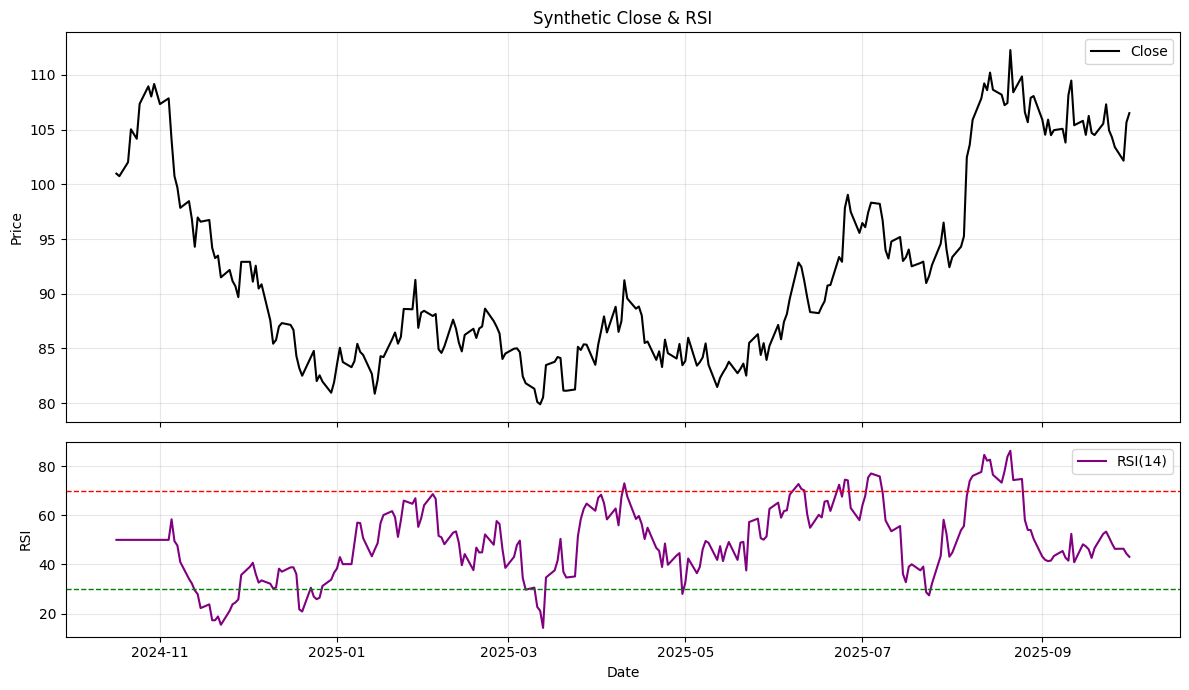

Mode: Synthetic
Rows: 250
Last Close: 106.5
Last RSI(14): 43.1


In [2]:
# ==== RSI Indicator Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # used only if RUN_MODE="yfinance"
PERIOD     = "1y"          # yfinance only
INTERVAL   = "1d"          # yfinance only
RSI_LEN    = 14
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        close = pd.to_numeric(df["Close"], errors="coerce").dropna()
        title = f"{TICKER} Close & RSI"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=250)
    mu, sigma, dt = 0.12, 0.30, 1/252
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    title = "Synthetic Close & RSI"

# 2) RSI Calculation (Wilder’s smoothing)
delta = close.diff()
gain = np.where(delta > 0, delta, 0.0)
loss = np.where(delta < 0, -delta, 0.0)

roll_up = pd.Series(gain, index=close.index).rolling(RSI_LEN).mean()
roll_down = pd.Series(loss, index=close.index).rolling(RSI_LEN).mean()

RS = roll_up / roll_down.replace(0, np.nan)
RSI = 100 - (100 / (1 + RS))
RSI = RSI.fillna(50)  # neutral before enough data

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Price chart
ax1.plot(close.index, close, label="Close", color="black")
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# RSI chart
ax2.plot(RSI.index, RSI, label=f"RSI({RSI_LEN})", color="purple")
ax2.axhline(70, color="red", linestyle="--", linewidth=1)
ax2.axhline(30, color="green", linestyle="--", linewidth=1)
ax2.set_ylabel("RSI")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"Last RSI({RSI_LEN}):", round(RSI.iloc[-1],2))
